<a href="https://colab.research.google.com/github/wonderalexandre/mmcfilters/blob/main/notebooks/Self_Dual_Residual_Trees_Tutorial_Static.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Static tree of shapes and residual trees tutorial

This version uses `dat/hydrant_2_3bit.png` and contains no widgets, browser callbacks, or interactive plots. `mmcfilters` constructs and filters the hierarchies, `mtviz.PrintTree` prints their complete topology, and Matplotlib records the input and filtered images as static notebook outputs.

# Installation on Google Colab

## Goal

The notebook has four steps:

1. load and display `dat/hydrant_2_3bit.png`;
2. construct a tree of shapes and two residual trees;
3. print all three trees with `mtviz.PrintTree`; and
4. apply fixed thresholds for six attributes and display every filtered image.

In [1]:
!pip install mmcfilters MorphoTreeViz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 4.4 MB/s eta 0:00:00


In [2]:
!wget https://www.dropbox.com/scl/fi/3p3nc8cpshbtdzkypo9m3/hydrant_2_3bit.png?rlkey=3mr0s0i9ki0qxb9bypr3yk4jn -O hydrant_2_3bit.png

--2026-08-30 23:33:09--  https://www.dropbox.com/scl/fi/3p3nc8cpshbtdzkypo9m3/hydrant_2_3bit.png?rlkey=3mr0s0i9ki0qxb9bypr3yk4jn
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uceb3f21ac7a6f157b12fe7c3ac2.dl.dropboxusercontent.com/cd/0/inline/DHNYNmVYvGIwDvLQmxp2M8xi1ZRpKjrCLV9ySRKcuuJ0GpnmlZNzKGQ-kQB-YKPGpW26yr-cTGQROR3BxU4g304Pn2krMX_vFr1FJ-_gT6FkIGVqaT9UTisZPuUWOMb11HA/file# [following]
--2026-08-30 23:33:10--  https://uceb3f21ac7a6f157b12fe7c3ac2.dl.dropboxusercontent.com/cd/0/inline/DHNYNmVYvGIwDvLQmxp2M8xi1ZRpKjrCLV9ySRKcuuJ0GpnmlZNzKGQ-kQB-YKPGpW26yr-cTGQROR3BxU4g304Pn2krMX_vFr1FJ-_gT6FkIGVqaT9UTisZPuUWOMb11HA/file
Resolving uceb3f21ac7a6f157b12fe7c3ac2.dl.dropboxusercontent.com (uceb3f21ac7a6f157b12fe7c3ac2.dl.dropboxusercontent.com)... 162.125.3.15, 2620:100:601b:15::a27d:80f
Connecting to u

## Setup

Run from the repository root or from `notebooks/`, using the project environment described in `README.md` and `notebooks/requirements.txt`.

,hydrant_2_3bit.png
path,hydrant_2_3bit.png
shape,352 x 363
pixels,127776
gray levels,5
range,109 .. 255


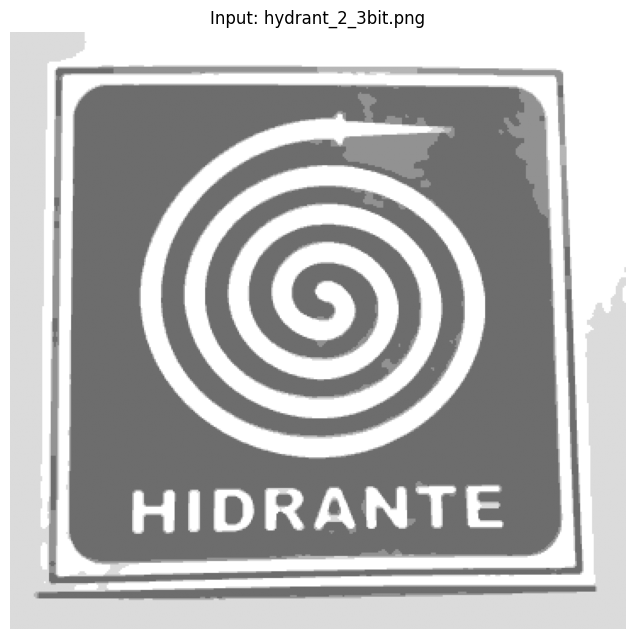

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mmcfilters
import mtviz as viz
import numpy as np
import pandas as pd
from IPython.display import display

IMAGE_PATH = Path("hydrant_2_3bit.png")
if not IMAGE_PATH.exists():
    IMAGE_PATH = Path("dat/hydrant_2_3bit.png")

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
assert image is not None, f"Could not read {IMAGE_PATH}"
image = np.ascontiguousarray(image, dtype=np.uint8)
rows, columns = image.shape

display(
    pd.Series(
        {
            "path": IMAGE_PATH.as_posix(),
            "shape": f"{rows} x {columns}",
            "pixels": image.size,
            "gray levels": np.unique(image).size,
            "range": f"{image.min()} .. {image.max()}",
        },
        name="hydrant_2_3bit.png",
    ).to_frame()
)

INPUT_FIGURE_WIDTH = 8
figure, axis = plt.subplots(
    figsize=(INPUT_FIGURE_WIDTH, INPUT_FIGURE_WIDTH * rows / columns)
)
axis.imshow(image, cmap="gray", vmin=0, vmax=255)
axis.set_title("Input: hydrant_2_3bit.png")
axis.axis("off")
plt.show()

## 1. Build the hierarchies

The residual trees use shared 8-adjacency. The tree of shapes uses the library's default complementary Min4/Max8 convention.

In [4]:
RESIDUAL_RADIUS = 1.5
INFINITY_PIXEL = 0

factory = mmcfilters.MorphologicalTreeFactory
trees = {
    "Tree of Shapes": factory.create_tree_of_shapes(
        image, infinity_pixel=INFINITY_PIXEL
    ),
    "Saturated Residual": factory.create_saturated_residual_tree(
        image, infinity_pixel=INFINITY_PIXEL, radius=RESIDUAL_RADIUS
    ),
    "Unrestricted Residual": factory.create_unrestricted_residual_tree(
        image, radius=RESIDUAL_RADIUS
    ),
}

areas = {
    name: mmcfilters.Attribute.compute_single_topology_attribute(
        tree, mmcfilters.Attribute.AREA, dtype=np.float64
    )
    for name, tree in trees.items()
}

display(
    pd.DataFrame(
        [
            {
                "hierarchy": name,
                "nodes": tree.num_nodes,
                "leaves": len(tree.leaves),
                "root altitude": int(tree.node_altitude(tree.root)),
            }
            for name, tree in trees.items()
        ]
    ).set_index("hierarchy")
)

,nodes,leaves,root altitude
hierarchy,,,
Tree of Shapes,81,36,219
Saturated Residual,81,36,219
Unrestricted Residual,80,36,109


## 2. Print the complete trees with `mtviz.PrintTree`

Each textual node uses the compact label `id|h=altitude|r=residue|A=support area`. The output is intentionally complete and may require horizontal scrolling.

In [5]:
for tree_name, tree in trees.items():
    area = areas[tree_name]
    print(f"\n{tree_name} ({tree.num_nodes} nodes)")
    print_tree = viz.PrintTree(
        tree.children,
        lambda node, tree=tree, area=area: (
            f"{node}"
            #f"{node}|h={int(tree.node_altitude(node))}"
            #f"|r={int(tree.node_residue(node))}|A={int(area[node])}"
        ),
    )
    print_tree(tree.root)


Tree of Shapes (81 nodes)
                                                  0
┌─┬─┬─┬─┬──────────────────────────────┬──────────┴─────────────────────────────────────────────────┐
1 2 3 4 5                              7                                                            8 
|                   ┌─────────────┬────┴───────────────────┐                                        | 
6                   9             11                       22                                       10
          ┌──┬──┬──┬┴─┬──┬──┬──┐  |  ┌─────────────────────┴──────────────────────┐                 | 
          12 13 14 16 17 18 19 20 21 23                                           24                15
                                                                                  |                   
                                                                                  25                  
                                                                   ┌──────────────┴──────────────┐

## 3. Apply fixed attribute filters

The thresholds below match the initial values of the interactive tutorial. For each attribute, `mmcfilters.Attribute` computes the node values, `mmcfilters.AttributeFilters` performs pruning-min, and Matplotlib records one static row containing the three reconstructions.

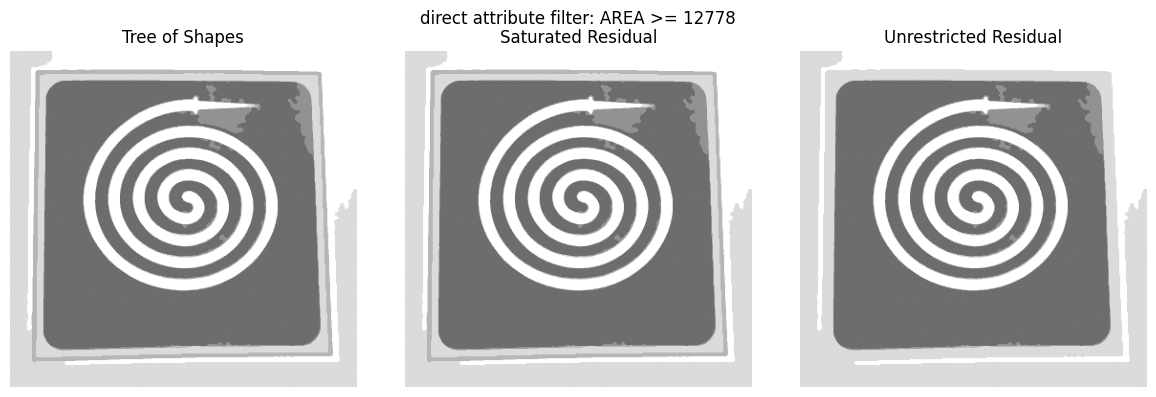

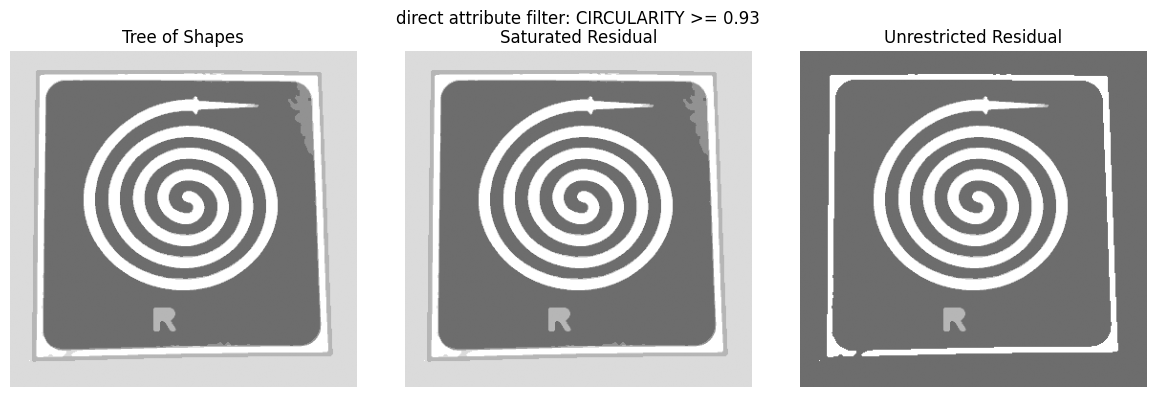

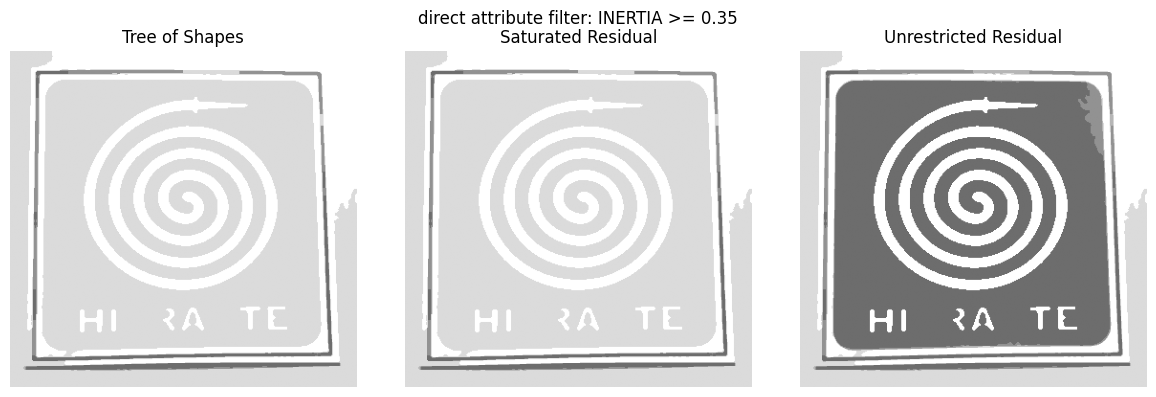

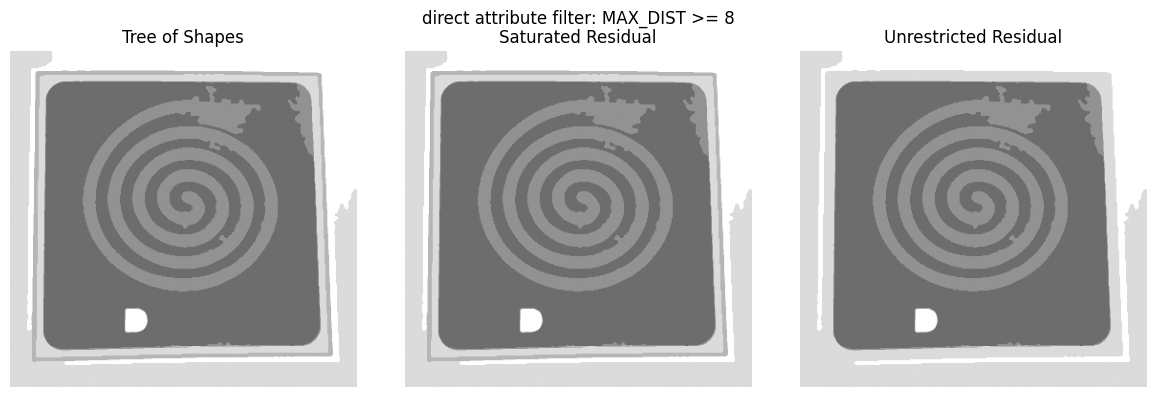

In [6]:
FILTER_SPECS = {
    "AREA": (mmcfilters.Attribute.AREA, float(np.ceil(0.1 * image.size))),
    "CIRCULARITY": (mmcfilters.Attribute.CIRCULARITY, 0.93),
    "INERTIA": (mmcfilters.Attribute.INERTIA, 0.35),
    "MAX_DIST": (mmcfilters.Attribute.MAX_DIST, 8),
}
FILTER_FIGURE_SIZE = (12, 4)

filtered_results = {}

for attribute_name, (attribute, threshold) in FILTER_SPECS.items():
    figure, axes = plt.subplots(1, len(trees), figsize=FILTER_FIGURE_SIZE)

    for axis, (tree_name, tree) in zip(axes, trees.items()):
        values = mmcfilters.Attribute.compute_single_topology_attribute(
            tree, attribute, dtype=np.float64
        )

        keep = (values > threshold).tolist()
        keep[tree.root] = True
        preservation_mask = mmcfilters.NodePreservationMask(keep)
        filtered_image = mmcfilters.DirectAttributeFilter(tree).apply(preservation_mask)

        filtered_results[(attribute_name, tree_name)] = filtered_image

        axis.imshow(filtered_image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(tree_name)
        axis.axis("off")


    figure.suptitle(f"direct attribute filter: {attribute_name} >= {threshold:g}")
    figure.tight_layout()
    plt.show()

